In [13]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### Phần 1 - Thống kê mô tả & đặc trưng

In [14]:
# Doc du lieu
df = sns.load_dataset("iris")
# Hien thi 5 dong dau
print(df.head())
# Cho biet (so dong, so cot)
print(df.shape)
# Kieu du lieu tung cot
print(df.dtypes)

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
(150, 5)
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object


In [15]:
# Tinh mean, median, mode, var, std, min, max, Q1, Q3, IQR cho moi bien
df_num = df.select_dtypes(include='number')
summary_df = df_num.agg(['mean', 'median', 'var', 'std', 'min', 'max'])
summary_df.loc['mode'] = df_num.mode().iloc[0]
summary_df.loc['Q1'] = df_num.quantile(0.25)
summary_df.loc['Q3'] = df_num.quantile(0.75)
summary_df.loc['IQR'] = summary_df.loc['Q3'] - summary_df.loc['Q1']
print(summary_df)

        sepal_length  sepal_width  petal_length  petal_width
mean        5.843333     3.057333      3.758000     1.199333
median      5.800000     3.000000      4.350000     1.300000
var         0.685694     0.189979      3.116278     0.581006
std         0.828066     0.435866      1.765298     0.762238
min         4.300000     2.000000      1.000000     0.100000
max         7.900000     4.400000      6.900000     2.500000
mode        5.000000     3.000000      1.400000     0.200000
Q1          5.100000     2.800000      1.600000     0.300000
Q3          6.400000     3.300000      5.100000     1.800000
IQR         1.300000     0.500000      3.500000     1.500000


In [16]:
# Tinh mean va std theo species
df.groupby('species').agg(['mean', 'std'])

sepal_length           sepal_width           petal_length  \
                   mean       std        mean       std         mean   
species                                                                
setosa            5.006  0.352490       3.428  0.379064        1.462   
versicolor        5.936  0.516171       2.770  0.313798        4.260   
virginica         6.588  0.635880       2.974  0.322497        5.552   

                     petal_width            
                 std        mean       std  
species                                     
setosa      0.173664       0.246  0.105386  
versicolor  0.469911       1.326  0.197753  
virginica   0.551895       2.026  0.274650

Nhận xét: Nhóm Setosa có sự khác biệt rõ rệt nhất so với hai nhóm còn lại.

### Phần 2 - Phân phối xác suất

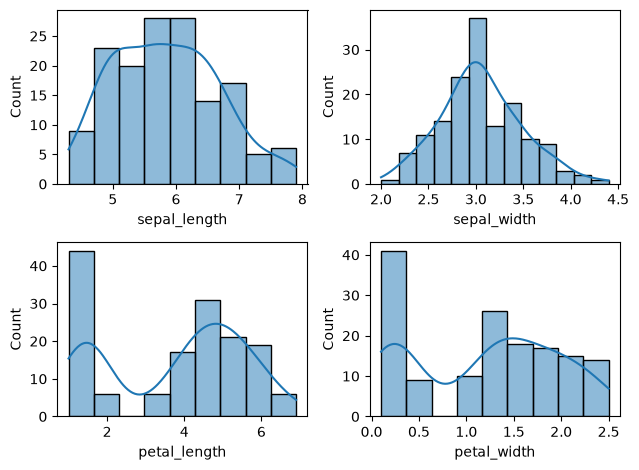

In [17]:
# Ve histogram + KDE tung bien
features = df.columns[:-1]
fig, axes = plt.subplots(2, 2)
for feature, ax in zip(features, axes.flatten()):
  sns.histplot(data=df, x=feature, kde=True, ax=ax)
plt.tight_layout()
plt.show()

Nhận xét:
- Biến sepal_width có phân phối khá cân đối, gần với phân phối chuẩn.
- Biến petal_length và petal_width có hiện tượng nhiều đỉnh.

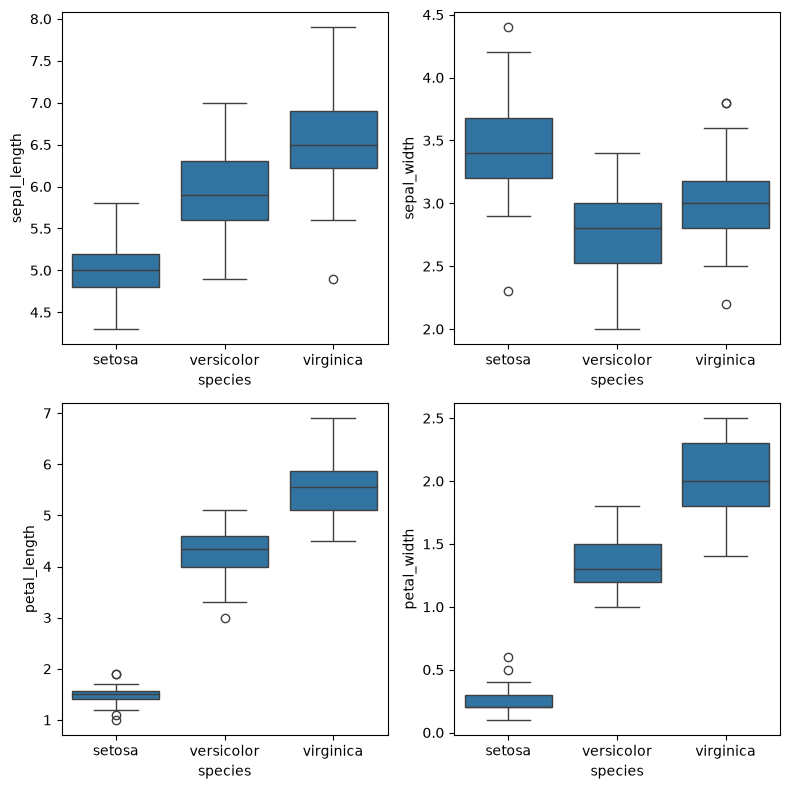

In [18]:
# Ve boxplot cho tung bien theo nhom
features = df.columns[:-1]
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
for feature, ax in zip(features, axes.flatten()):
  sns.boxplot(data=df, x='species', y=feature, ax=ax)
plt.tight_layout()
plt.show()

Nhận xét:
- Setosa có số liệu tách biệt hoàn toàn so với 2 nhóm còn lại.
- Setosa có độ phân tán thấp so với 2 nhóm còn lại (trừ feature sepal_width).
- Outliers xuất hiện ở cả 3 loài trên các biến khác nhau, nhưng nhiều nhất là ở nhóm Setosa.

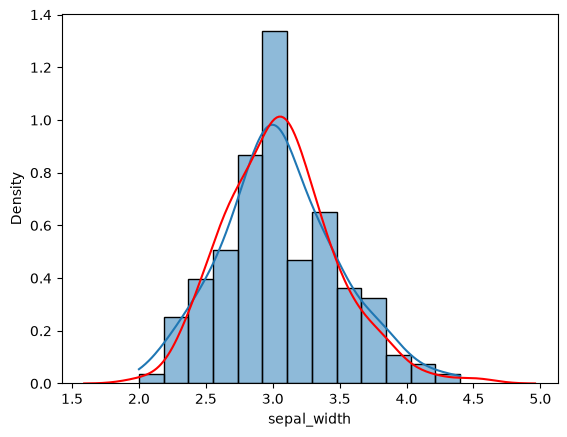

In [26]:
# Ve histogram thuc te so voi duong PDF ly thueyt
feature = 'sepal_width'
mean = df[feature].mean()
std = df[feature].std()
sns.histplot(data=df, x=feature, kde=True, stat="density")
norm_data = np.random.normal(mean, std, len(df))
sns.kdeplot(norm_data, color='red')
plt.show()

Nhận xét: Dữ liệu thực tế khá khớp với đường PDF lý thuyết, cho thấy phân phối của sepal_width rất gần với phân phổi chuẩn.

### Phần 3 - Phân tích đa biến & tương quan

In [20]:
# Tinh ma tran covariance
print(df_num.cov())
# Tinh ma tran correlation
print(df_num.corr())

              sepal_length  sepal_width  petal_length  petal_width
sepal_length      0.685694    -0.042434      1.274315     0.516271
sepal_width      -0.042434     0.189979     -0.329656    -0.121639
petal_length      1.274315    -0.329656      3.116278     1.295609
petal_width       0.516271    -0.121639      1.295609     0.581006
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.117570      0.871754     0.817941
sepal_width      -0.117570     1.000000     -0.428440    -0.366126
petal_length      0.871754    -0.428440      1.000000     0.962865
petal_width       0.817941    -0.366126      0.962865     1.000000


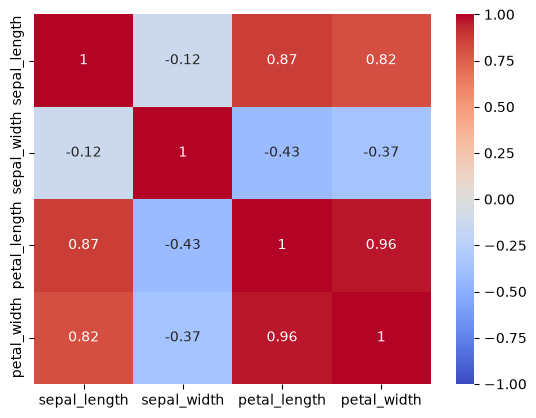

In [21]:
# Ve heatmap tuong quan
sns.heatmap(df_num.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

Nhận xét:
- petal_length và petal_width là cặp biến có tương quan mạnh nhất.
- sepal_length cũng có tương quan mạnh với cả petal_length và petal_width.

--> Có hiện tượng đa cộng tuyến.

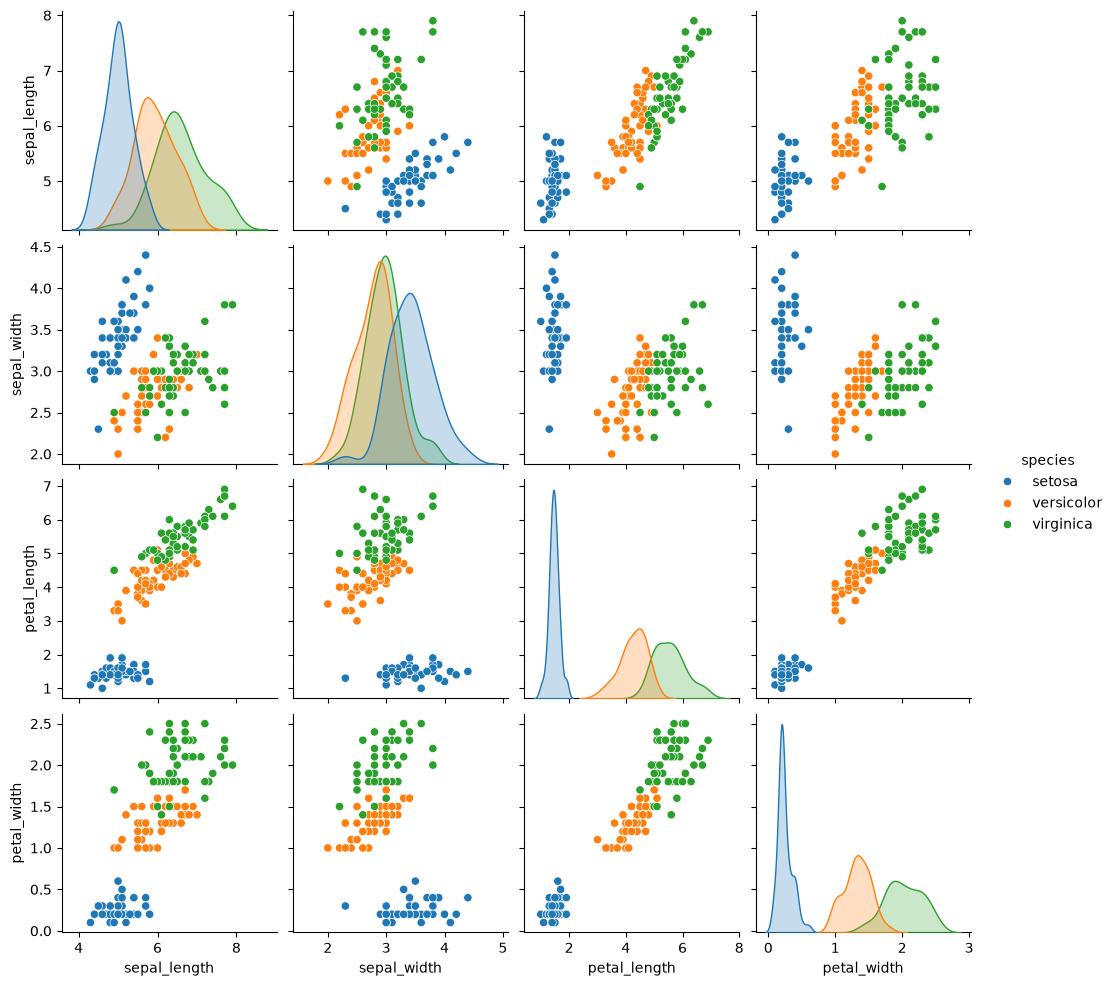

In [22]:
# Ve pairplot
sns.pairplot(df, hue="species")
plt.show()

Nhận xét:
- Loài setosa tách biệt hoàn toàn thành một cụm riêng biệt trên tất cả các biểu đồ scatter plot theo cặp --> có sự khác biệt rõ với 2 cặp còn lại.
- Cặp biến petal_length và petal_width tạo thành một đường phân bố hẹp, dốc lên rất rõ ràng cho cả 3 loài --> có quan hệ tuyến tính rõ ràng. Cặp sepal_length với petal_length và sepal_length với petal_width có đường phân bố phân tán hơn nhưng vẫn có xu hướng dốc lên rõ ràng, thể hiện xu hướng tuyến tính tương tự.

### Phần 4 - Xác suất & Định lí Bayes

In [23]:
# Tinh xac suat hau nghiem P(B|+) bang dinh li Bayes
P_B = 0.01
P_pos_givenB = 0.99
P_pos_givnNB = 0.05
P_NB = 1 - P_B

P_pos = P_pos_givenB * P_B + P_pos_givnNB * P_NB
P_B_given_pos = P_pos_givenB * P_B / P_pos
print(round(P_B_given_pos, 4))

0.1667


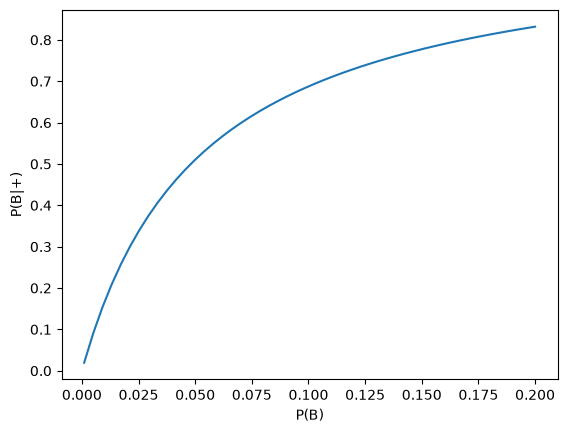

In [24]:
# Tinh xac suat hau nghiem P(B|+) voi P(B) thay doi
P_B_arr = np.linspace(0.001, 0.2)
P_pos_givenB = 0.99
P_pos_givnNB = 0.05
P_NB = 1 - P_B_arr

P_pos = P_pos_givenB * P_B_arr + P_pos_givnNB * P_NB
P_B_given_pos = P_pos_givenB * P_B_arr / P_pos

# Ve do thi
plt.plot(P_B_arr, P_B_given_pos)
plt.xlabel("P(B)")
plt.ylabel("P(B|+)")
plt.show()

Khi bệnh hiếm (P(B) nhỏ), kết quả sẽ phản trực giác: độ nhạy lớn (P(+|B)=0.99) nhưng khi nhận kết quả xét nghiệm dương tính thì xác suất thật sự mắc bệnh (P(B|+)) lại rất nhỏ. Điều này là do số người không mắc bệnh nhiều, mà tỉ lệ dương tính giả không đổi (luôn = 5% trên tổng số người không mắc bệnh) --> số ca dương tính giả tăng, áp đảo hoàn toàn số ca dương tính thật --> xác suất một người dương tính thực sự mắc bệnh trở nên cực kỳ thấp.